## The Normal Equation

We generate some linear-looking data to test the normal equation

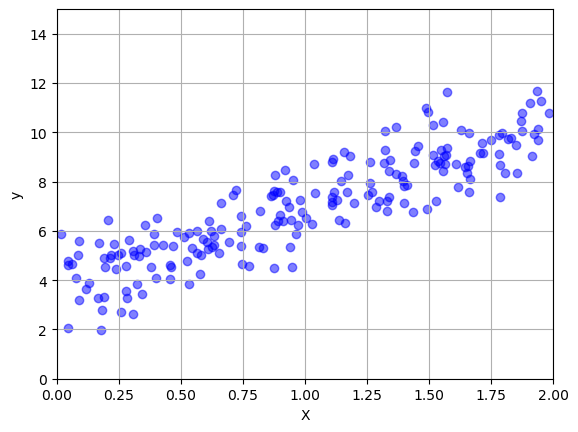

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m,1))
y = 4 + 3 * X + rng.standard_normal((m,1))

plt.scatter(X,y,c='blue', alpha=0.5)
plt.xlabel("X")
plt.ylabel("y")
plt.xlim(0,2)
plt.ylim(0,15)
plt.grid()
plt.show()

Let's compute the predicted value $\hat{\theta}$ using the normal equation.
Note that the '@' operator performs matrix multiplication, equivalent to np.matmul()

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(theta_best)

[[3.69084138]
 [3.32960458]]


In [3]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print(y_predict)

[[ 3.69084138]
 [10.35005055]]


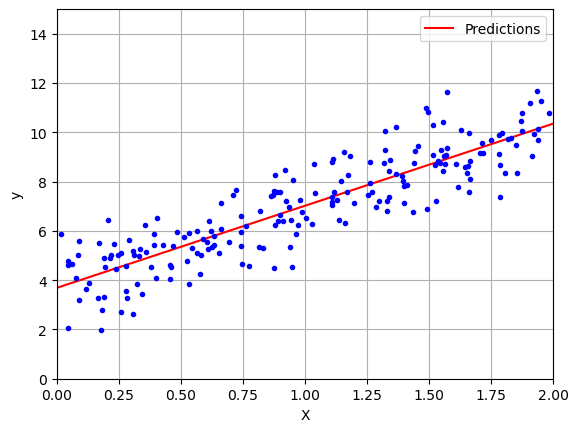

In [4]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.grid('True')
plt.xlim(0,2)
plt.ylim(0,15)
plt.legend()
plt.show()

Using the Scikit-Learn, performing linear regression is much more straightforward.

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print("The intercept is: ",lr.intercept_," and the coefficient is: ", lr.coef_)
print("The predicted value of y is: ",lr.predict(X_new))

The intercept is:  [3.69084138]  and the coefficient is:  [[3.32960458]]
The predicted value of y is:  [[ 3.69084138]
 [10.35005055]]


## Gradient Descent

In [6]:
alpha = 0.1 
n_epochs = 1000
m=len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
    gradients = (2/m) * (X_b.T) @ (X_b @ theta - y)
    theta = theta - (alpha * gradients)

print(theta)


[[3.69084138]
 [3.32960458]]


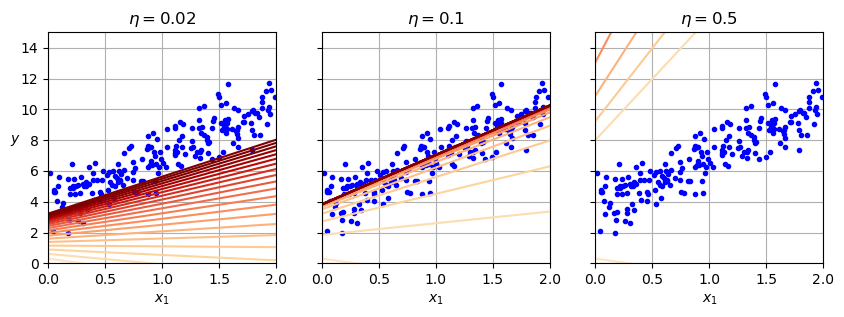

In [7]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

plt.figure(figsize=(10,3))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)

plt.show()